# Gemma Reproduction of arXiv 2505.07917v2

This notebook follows the biomedical RAG experiments from `2505.07917v2.pdf` and replaces the paper's GPT-3.5 generation step with Google Gemma. Secrets are read from Colab Secrets or environment variables only; no API key is stored in the notebook.

In [3]:
# 1. Install Colab Dependencies and Extensions
import importlib.util
import os
import subprocess
import sys

IN_COLAB = importlib.util.find_spec('google.colab') is not None
PACKAGE_IMPORTS = {
    'google-genai': 'google.genai',
    'pypdf': 'pypdf',
    'pandas': 'pandas',
    'scikit-learn': 'sklearn',
    'matplotlib': 'matplotlib',
    'requests': 'requests',
    'tqdm': 'tqdm',
}
missing = [pkg for pkg, module in PACKAGE_IMPORTS.items() if importlib.util.find_spec(module) is None]
if IN_COLAB and missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
print({'in_colab': IN_COLAB, 'missing_before_optional_install': missing})

{'in_colab': False, 'missing_before_optional_install': []}


In [4]:
# 2. Configure Runtime, Paths, and Secrets
import getpass
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

SEED = int(os.getenv('RAG_SEED', '42'))
random.seed(SEED)
np.random.seed(SEED)

cwd = Path.cwd().resolve()
env_project_root = os.getenv('PROJECT_ROOT')
if env_project_root:
    PROJECT_ROOT = Path(env_project_root).resolve()
else:
    PROJECT_ROOT = next(
        (candidate for candidate in [cwd, *cwd.parents, Path('/content/medical_RAG_system')] if (candidate / 'rag_system').exists()),
        cwd,
    )

OUTPUT_DIR = Path(os.getenv('RAG_OUTPUT_DIR', PROJECT_ROOT / 'evaluation' / 'gemma_reproduction_outputs')).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GEMMA_MODEL = os.getenv('GEMMA_MODEL', 'gemma-4-32b-it')

def configure_google_key(prompt_if_missing=False):
    for name in ['GOOGLE_API_KEY', 'GEMINI_API_KEY', 'GEMMA_API_KEY']:
        value = os.getenv(name)
        if value:
            os.environ['GOOGLE_API_KEY'] = value
            return name
    if IN_COLAB:
        try:
            from google.colab import userdata
            value = userdata.get('GOOGLE_API_KEY') or userdata.get('GEMINI_API_KEY') or userdata.get('GEMMA_API_KEY')
            if value:
                os.environ['GOOGLE_API_KEY'] = value
                return 'colab_secret'
        except Exception as exc:
            print(f'Colab secret lookup skipped: {exc}')
    if prompt_if_missing:
        os.environ['GOOGLE_API_KEY'] = getpass.getpass('Google API key: ')
        return 'prompt'
    return None

secret_source = configure_google_key(prompt_if_missing=False)
print({'project_root': str(PROJECT_ROOT), 'output_dir': str(OUTPUT_DIR), 'gemma_model': GEMMA_MODEL, 'secret_loaded_from': secret_source})

{'project_root': 'L:\\Works\\Freelance\\medical_RAG_system', 'output_dir': 'L:\\Works\\Freelance\\medical_RAG_system\\evaluation\\gemma_reproduction_outputs', 'gemma_model': 'gemma-4-32b-it', 'secret_loaded_from': None}


In [5]:
# 3. Load and Parse the Research PDF
import re
from pypdf import PdfReader

pdf_candidates = [PROJECT_ROOT / '2505.07917v2.pdf', cwd / '2505.07917v2.pdf', Path('/content/2505.07917v2.pdf')]
pdf_path = next((path for path in pdf_candidates if path.exists()), None)
if pdf_path is None:
    raise FileNotFoundError('Place 2505.07917v2.pdf in the project root or current working directory.')

reader = PdfReader(str(pdf_path))
paper_text = '\n'.join((page.extract_text() or '') for page in reader.pages)
section_headings = re.findall(r'^(?:[IVX]+\.|[A-Z]\.)\s+[^\n]+', paper_text, flags=re.MULTILINE)
metric_terms = sorted(set(re.findall(r'\b(?:accuracy|recall|precision|F1 Score|response time|indexing speed|retrieval time|total time)\b', paper_text, flags=re.IGNORECASE)))
print({'pdf': str(pdf_path), 'pages': len(reader.pages), 'chars': len(paper_text), 'sections_found': section_headings[:8], 'metrics_found': metric_terms})

{'pdf': 'L:\\Works\\Freelance\\medical_RAG_system\\2505.07917v2.pdf', 'pages': 4, 'chars': 23716, 'sections_found': ['I. INTRODUCTION', 'II. BIOMEDICALQUESTION-ANSWERING WITHRAG', 'III. EXPERIMENTALEVALUATION', 'A. Experimental Setup', 'B. Indexing and Query Time', 'C. Document Relevancy', 'D. Answer Correctness of the RAG System (End-to-End)', 'IV. EVALUATION OF THEFINALSYSTEM'], 'metrics_found': ['Accuracy', 'F1 Score', 'F1 score', 'Indexing Speed', 'Precision', 'Recall', 'Response Time', 'Retrieval Time', 'Total Time', 'accuracy', 'indexing speed', 'precision', 'recall', 'response time', 'retrieval time']}


In [6]:
# 4. Extract Experimental Protocol From the Paper
paper_protocol = {
    'dataset': 'BioASQ Task-B yes/no questions over PubMed abstracts; 2.4M subset for component analysis and 24M PubMed corpus for final system.',
    'document_fields': ['PMID', 'title', 'abstract/content'],
    'retrievers': ['BM25', 'BioBERT', 'MedCPT', 'Hybrid BM25 + MedCPT cross-encoder'],
    'stores': ['MongoDB sparse TF-IDF', 'Elasticsearch sparse BM25', 'Elasticsearch dense KNN', 'FAISS dense L2'],
    'generator_original': 'GPT-3.5-turbo, API version May 2024, temperature=0',
    'generator_reproduction': GEMMA_MODEL,
    'prompt_parts': ['system prompt', 'user question', 'retrieved documents with PMIDs, titles, content, scores'],
    'reported_metrics': ['index response time', 'indexing speed', 'retriever recall', 'retriever precision', 'accuracy', 'recall', 'precision', 'F1 score', 'retrieval time', 'total time'],
}
pd.Series(paper_protocol)

dataset                   BioASQ Task-B yes/no questions over PubMed abs...
document_fields                             [PMID, title, abstract/content]
retrievers                [BM25, BioBERT, MedCPT, Hybrid BM25 + MedCPT c...
stores                    [MongoDB sparse TF-IDF, Elasticsearch sparse B...
generator_original        GPT-3.5-turbo, API version May 2024, temperatu...
generator_reproduction                                       gemma-4-32b-it
prompt_parts              [system prompt, user question, retrieved docum...
reported_metrics          [index response time, indexing speed, retrieve...
dtype: object

In [7]:
# 5. Create Experiment Configuration Registry
from dataclasses import asdict, dataclass

@dataclass
class ExperimentConfig:
    name: str
    family: str
    retriever_id: int | None
    retriever_name: str | None
    retrieval_depth: int | None
    rerank_top_n: int | None
    question_type: int | None
    model: str
    temperature: float
    max_tokens: int
    seed: int
    output_path: str

retriever_map = {1: 'BioBERT', 2: 'BM25', 3: 'Hybrid BM25 + MedCPT', 4: 'MedCPT'}
experiment_registry = []
for retriever_id, retriever_name in retriever_map.items():
    experiment_registry.append(ExperimentConfig(f'e2e_{retriever_name.lower().replace(" ", "_")}', 'end_to_end', retriever_id, retriever_name, 50 if retriever_id == 3 else None, 10, 2, GEMMA_MODEL, 0.0, 500, SEED, str(OUTPUT_DIR / f'e2e_retriever_{retriever_id}.json')))
for depth in [20, 50, 100]:
    experiment_registry.append(ExperimentConfig(f'hybrid_depth_{depth}', 'retrieval_depth_ablation', 3, 'Hybrid BM25 + MedCPT', depth, 10, 2, GEMMA_MODEL, 0.0, 500, SEED, str(OUTPUT_DIR / f'hybrid_depth_{depth}.json')))
registry_df = pd.DataFrame([asdict(config) for config in experiment_registry])
registry_df

,name,family,retriever_id,retriever_name,retrieval_depth,rerank_top_n,question_type,model,temperature,max_tokens,seed,output_path
0,e2e_biobert,end_to_end,1,BioBERT,NaN,10,2,gemma-4-32b-it,0.0,500,42,L:\Works\Freelance\medical_RAG_system\evaluati...
1,e2e_bm25,end_to_end,2,BM25,NaN,10,2,gemma-4-32b-it,0.0,500,42,L:\Works\Freelance\medical_RAG_system\evaluati...
2,e2e_hybrid_bm25_+_medcpt,end_to_end,3,Hybrid BM25 + MedCPT,50.0,10,2,gemma-4-32b-it,0.0,500,42,L:\Works\Freelance\medical_RAG_system\evaluati...
3,e2e_medcpt,end_to_end,4,MedCPT,NaN,10,2,gemma-4-32b-it,0.0,500,42,L:\Works\Freelance\medical_RAG_system\evaluati...
4,hybrid_depth_20,retrieval_depth_ablation,3,Hybrid BM25 + MedCPT,20.0,10,2,gemma-4-32b-it,0.0,500,42,L:\Works\Freelance\medical_RAG_system\evaluati...
5,hybrid_depth_50,retrieval_depth_ablation,3,Hybrid BM25 + MedCPT,50.0,10,2,gemma-4-32b-it,0.0,500,42,L:\Works\Freelance\medical_RAG_system\evaluati...
6,hybrid_depth_100,retrieval_depth_ablation,3,Hybrid BM25 + MedCPT,100.0,10,2,gemma-4-32b-it,0.0,500,42,L:\Works\Freelance\medical_RAG_system\evaluati...


In [8]:
# 6. Prepare Datasets Described in the Paper
BIOASQ_YESNO_JSON = Path(os.getenv('BIOASQ_YESNO_JSON', PROJECT_ROOT / 'data' / 'bioASQ' / 'yesno_questions.json'))
PUBMED_SUBSET_DIR = Path(os.getenv('PUBMED_SUBSET_DIR', PROJECT_ROOT / 'data' / 'pubmed' / 'chunk'))

def load_bioasq_questions(path):
    path = Path(path)
    if not path.exists():
        return {'available': False, 'path': str(path), 'questions': []}
    with path.open('r', encoding='utf-8') as file:
        data = json.load(file)
    questions = data.get('questions', data if isinstance(data, list) else [])
    return {'available': True, 'path': str(path), 'questions': questions}

def filter_yesno_questions(questions):
    return [question for question in questions if question.get('type') == 'yesno' and question.get('documents')]

dataset_state = load_bioasq_questions(BIOASQ_YESNO_JSON)
yesno_questions = filter_yesno_questions(dataset_state['questions'])
dataset_summary = {
    'bioasq_available': dataset_state['available'],
    'bioasq_path': dataset_state['path'],
    'yesno_questions': len(yesno_questions),
    'pubmed_subset_dir_exists': PUBMED_SUBSET_DIR.exists(),
    'pubmed_jsonl_files_visible': len(list(PUBMED_SUBSET_DIR.glob('*.jsonl'))) if PUBMED_SUBSET_DIR.exists() else 0,
}
dataset_summary

{'bioasq_available': False,
 'bioasq_path': 'L:\\Works\\Freelance\\medical_RAG_system\\data\\bioASQ\\yesno_questions.json',
 'yesno_questions': 0,
 'pubmed_subset_dir_exists': False,
 'pubmed_jsonl_files_visible': 0}

In [9]:
# 7. Implement Prompt Templates From the Paper
SYSTEM_PROMPT = (
    'You are a scientific medical assistant designed to synthesize responses from specific medical documents. '
    'Only use the information provided in the documents to answer questions. The first documents should be the most relevant. '
    'Do not use any other information except for the documents provided. When answering questions, always format your response '
    'as a JSON object with fields for response and used_PMIDs. Cite all PMIDs your response is based on in used_PMIDs.'
)

def render_paper_prompt(question, docs):
    context_docs = {
        f'doc{idx + 1}': {
            'PMID': doc.get('PMID'),
            'title': doc.get('title'),
            'content': doc.get('content'),
            'relevance_score': doc.get('score'),
        }
        for idx, doc in enumerate(docs)
    }
    return {
        'system': SYSTEM_PROMPT,
        'user': f'Answer the following question: {question}',
        'context': context_docs,
    }

render_paper_prompt('Is stop codon bypass possible?', [{'PMID': 1814364, 'title': 'Example', 'content': 'Stop codon bypass can occur.', 'score': 1.0}])

{'system': 'You are a scientific medical assistant designed to synthesize responses from specific medical documents. Only use the information provided in the documents to answer questions. The first documents should be the most relevant. Do not use any other information except for the documents provided. When answering questions, always format your response as a JSON object with fields for response and used_PMIDs. Cite all PMIDs your response is based on in used_PMIDs.',
 'user': 'Answer the following question: Is stop codon bypass possible?',
 'context': {'doc1': {'PMID': 1814364,
   'title': 'Example',
   'content': 'Stop codon bypass can occur.',
   'relevance_score': 1.0}}}

In [10]:
# 8. Configure Gemma 4 32B API Client
import time

sys.path.insert(0, str(PROJECT_ROOT / 'rag_system'))
from gemma_chat import GemmaChat

class RetryingGemmaChat(GemmaChat):
    def create_chat_with_retries(self, user_message, retrieved_documents, retries=3, delay=2):
        last_response = None
        for attempt in range(1, retries + 1):
            last_response = self.create_chat(user_message, retrieved_documents)
            try:
                payload = json.loads(last_response)
                if 'error' not in payload:
                    return last_response
            except Exception:
                pass
            if attempt < retries:
                time.sleep(delay * attempt)
        return last_response

print({'gemma_model': GEMMA_MODEL, 'api_key_loaded': bool(os.getenv('GOOGLE_API_KEY'))})

{'gemma_model': 'gemma-4-32b-it', 'api_key_loaded': False}


In [11]:
# 9. Replace GPT-3.5 Calls With Gemma 4 32B
sys.path.insert(0, str(PROJECT_ROOT / 'evaluation' / 'evaluation_QA_system'))
from med_rag import MedRAG
from RAG_evaluator import RAG_evaluator

def build_gemma_rag(retriever_id, question_type=2, n_docs=10, retrieval_depth=None):
    return MedRAG(
        retriever=retriever_id,
        question_type=question_type,
        n_docs=n_docs,
        llm_provider='gemma',
        model=GEMMA_MODEL,
        retrieval_depth=retrieval_depth,
    )

replacement_summary = registry_df[['name', 'retriever_name', 'model', 'temperature', 'max_tokens']]
replacement_summary

,name,retriever_name,model,temperature,max_tokens
0,e2e_biobert,BioBERT,gemma-4-32b-it,0.0,500
1,e2e_bm25,BM25,gemma-4-32b-it,0.0,500
2,e2e_hybrid_bm25_+_medcpt,Hybrid BM25 + MedCPT,gemma-4-32b-it,0.0,500
3,e2e_medcpt,MedCPT,gemma-4-32b-it,0.0,500
4,hybrid_depth_20,Hybrid BM25 + MedCPT,gemma-4-32b-it,0.0,500
5,hybrid_depth_50,Hybrid BM25 + MedCPT,gemma-4-32b-it,0.0,500
6,hybrid_depth_100,Hybrid BM25 + MedCPT,gemma-4-32b-it,0.0,500


In [12]:
# 10. Run Baseline and Main Experiments
import requests

def check_elasticsearch():
    try:
        from elasticsearch import Elasticsearch
        password = os.getenv('ELASTIC_PASSWORD')
        client = Elasticsearch(['https://localhost:9200'], basic_auth=('elastic', password), verify_certs=False, request_timeout=5)
        return bool(client.ping())
    except Exception:
        return False

def check_faiss_server():
    try:
        response = requests.get(os.getenv('FAISS_URL', 'http://localhost:5000'), timeout=2)
        return response.status_code < 500
    except Exception:
        return False

preflight = {
    'google_api_key': bool(os.getenv('GOOGLE_API_KEY')),
    'bioasq_yesno_json': BIOASQ_YESNO_JSON.exists(),
    'elasticsearch': check_elasticsearch(),
    'faiss_server': check_faiss_server(),
}

def run_e2e_config(config):
    needs_faiss = config.retriever_id in {1, 4}
    if not preflight['google_api_key']:
        return {'name': config.name, 'status': 'skipped', 'reason': 'missing GOOGLE_API_KEY/GEMINI_API_KEY'}
    if not preflight['bioasq_yesno_json']:
        return {'name': config.name, 'status': 'skipped', 'reason': f'missing BioASQ file: {BIOASQ_YESNO_JSON}'}
    if not preflight['elasticsearch']:
        return {'name': config.name, 'status': 'skipped', 'reason': 'Elasticsearch pubmed_index is not reachable'}
    if needs_faiss and not preflight['faiss_server']:
        return {'name': config.name, 'status': 'skipped', 'reason': 'FAISS search server is not reachable'}
    rag = build_gemma_rag(config.retriever_id, question_type=config.question_type, n_docs=config.rerank_top_n or 10, retrieval_depth=config.retrieval_depth)
    evaluator = RAG_evaluator(rag, str(BIOASQ_YESNO_JSON), config.output_path)
    evaluator.run_eval()
    return {'name': config.name, 'status': 'completed', 'output_path': config.output_path}

RUN_FULL_EXPERIMENTS = os.getenv('RUN_FULL_EXPERIMENTS', '0') == '1'
run_status = []
if RUN_FULL_EXPERIMENTS:
    for config in experiment_registry:
        run_status.append(run_e2e_config(config))
else:
    run_status = [{'name': config.name, 'status': 'skipped', 'reason': 'set RUN_FULL_EXPERIMENTS=1 to execute expensive paper experiments'} for config in experiment_registry]
pd.DataFrame(run_status)

l:\Works\Freelance\medical_RAG_system\.venv\Lib\site-packages\elasticsearch\_sync\client\__init__.py:399: SecurityWarning: Connecting to 'https://localhost:9200' using TLS with verify_certs=False is insecure
  _transport = transport_class(


,name,status,reason
0,e2e_biobert,skipped,set RUN_FULL_EXPERIMENTS=1 to execute expensiv...
1,e2e_bm25,skipped,set RUN_FULL_EXPERIMENTS=1 to execute expensiv...
2,e2e_hybrid_bm25_+_medcpt,skipped,set RUN_FULL_EXPERIMENTS=1 to execute expensiv...
3,e2e_medcpt,skipped,set RUN_FULL_EXPERIMENTS=1 to execute expensiv...
4,hybrid_depth_20,skipped,set RUN_FULL_EXPERIMENTS=1 to execute expensiv...
5,hybrid_depth_50,skipped,set RUN_FULL_EXPERIMENTS=1 to execute expensiv...
6,hybrid_depth_100,skipped,set RUN_FULL_EXPERIMENTS=1 to execute expensiv...


In [13]:
# 11. Compute All Reported Metrics
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def safe_list(value):
    return value if isinstance(value, list) else []

def summarize_result_file(path):
    path = Path(path)
    if not path.exists():
        return {'path': str(path), 'status': 'missing'}
    with path.open('r', encoding='utf-8') as file:
        rows = json.load(file)
    df = pd.DataFrame(rows)
    y_true = df['trueresponse_exact'].astype(str).str.lower()
    y_pred = df['ragresponse'].astype(str).str.lower()
    retriever_recall = []
    retriever_precision = []
    used_recall = []
    used_precision = []
    for _, row in df.iterrows():
        gold = set(map(str, safe_list(row.get('pmids_ground_truth'))))
        retrieved = set(map(str, safe_list(row.get('pmids_retrieved'))))
        used = set(map(str, safe_list(row.get('pmids_uses_by_rag'))))
        retrieved_hits = gold & retrieved
        used_hits = gold & used
        retriever_recall.append(len(retrieved_hits) / len(gold) if gold else 0)
        retriever_precision.append(len(retrieved_hits) / len(retrieved) if retrieved else 0)
        used_recall.append(len(used_hits) / len(gold) if gold else 0)
        used_precision.append(len(used_hits) / len(used) if used else 0)
    return {
        'path': str(path),
        'status': 'computed',
        'n': len(df),
        'accuracy': accuracy_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'retriever_recall': float(np.mean(retriever_recall)),
        'retriever_precision': float(np.mean(retriever_precision)),
        'used_recall': float(np.mean(used_recall)),
        'used_precision': float(np.mean(used_precision)),
        'request_time_mean': float(df['requestime'].mean()),
        'retrieval_time_mean': float(df['retrievment_time'].mean()),
        'generation_time_mean': float(df['generation_time'].mean()),
    }

metrics_df = pd.DataFrame([summarize_result_file(config.output_path) | {'name': config.name, 'family': config.family, 'retriever': config.retriever_name} for config in experiment_registry])
metrics_df

,path,status,name,family,retriever
0,L:\Works\Freelance\medical_RAG_system\evaluati...,missing,e2e_biobert,end_to_end,BioBERT
1,L:\Works\Freelance\medical_RAG_system\evaluati...,missing,e2e_bm25,end_to_end,BM25
2,L:\Works\Freelance\medical_RAG_system\evaluati...,missing,e2e_hybrid_bm25_+_medcpt,end_to_end,Hybrid BM25 + MedCPT
3,L:\Works\Freelance\medical_RAG_system\evaluati...,missing,e2e_medcpt,end_to_end,MedCPT
4,L:\Works\Freelance\medical_RAG_system\evaluati...,missing,hybrid_depth_20,retrieval_depth_ablation,Hybrid BM25 + MedCPT
5,L:\Works\Freelance\medical_RAG_system\evaluati...,missing,hybrid_depth_50,retrieval_depth_ablation,Hybrid BM25 + MedCPT
6,L:\Works\Freelance\medical_RAG_system\evaluati...,missing,hybrid_depth_100,retrieval_depth_ablation,Hybrid BM25 + MedCPT


In [14]:
# 12. Reproduce Paper Tables
storage_reported = pd.DataFrame([
    {'method': 'MongoDB', 'type': 'Sparse TF-IDF', 'index_response_time': '26.4 s +/- 1.72 s', 'indexing_speed': '10.41 min'},
    {'method': 'Elasticsearch', 'type': 'Sparse BM25', 'index_response_time': '82 ms +/- 37 ms', 'indexing_speed': '156 min'},
    {'method': 'Elasticsearch', 'type': 'Dense KNN', 'index_response_time': '24.6 s +/- 1.23 s', 'indexing_speed': '171 min'},
    {'method': 'FAISS', 'type': 'Dense L2 Distance', 'index_response_time': '657 ms +/- 127 ms', 'indexing_speed': '41 min'},
])
retriever_reported = pd.DataFrame([
    {'retriever': 'Hybrid Retriever', 'vector_type': 'Hybrid', 'reported_recall': 0.567, 'reported_precision': 0.319},
    {'retriever': 'BM25', 'vector_type': 'Sparse', 'reported_recall': 0.537, 'reported_precision': 0.322},
    {'retriever': 'MedCPT', 'vector_type': 'Dense', 'reported_recall': 0.273, 'reported_precision': 0.205},
    {'retriever': 'BioBERT', 'vector_type': 'Dense', 'reported_recall': 0.070, 'reported_precision': 0.070},
])
e2e_reported = pd.DataFrame([
    {'paper_model': 'GPT-3.5 / Hybrid Retriever', 'accuracy': 0.86, 'recall': 0.86, 'precision': 0.89, 'f1': 0.86},
    {'paper_model': 'GPT-3.5 / MedCPT', 'accuracy': 0.83, 'recall': 0.83, 'precision': 0.86, 'f1': 0.84},
    {'paper_model': 'GPT-3.5 / BM25', 'accuracy': 0.72, 'recall': 0.72, 'precision': 0.83, 'f1': 0.74},
    {'paper_model': 'GPT-3.5 / BioBERT', 'accuracy': 0.63, 'recall': 0.63, 'precision': 0.85, 'f1': 0.67},
])
depth_reported = pd.DataFrame([
    {'docs': 20, 'accuracy': 0.89, 'recall': 0.88, 'precision': 0.89, 'f1': 0.88, 'retrieval_time_s': '0.39 +/- 0.07', 'total_time_s': '1.52 +/- 0.42'},
    {'docs': 50, 'accuracy': 0.90, 'recall': 0.90, 'precision': 0.89, 'f1': 0.90, 'retrieval_time_s': '0.82 +/- 0.13', 'total_time_s': '1.91 +/- 0.36'},
    {'docs': 100, 'accuracy': 0.87, 'recall': 0.87, 'precision': 0.88, 'f1': 0.87, 'retrieval_time_s': '1.54 +/- 0.16', 'total_time_s': '2.62 +/- 0.44'},
])
display(storage_reported)
display(retriever_reported)
display(e2e_reported)
display(depth_reported)
display(metrics_df)

,method,type,index_response_time,indexing_speed
0,MongoDB,Sparse TF-IDF,26.4 s +/- 1.72 s,10.41 min
1,Elasticsearch,Sparse BM25,82 ms +/- 37 ms,156 min
2,Elasticsearch,Dense KNN,24.6 s +/- 1.23 s,171 min
3,FAISS,Dense L2 Distance,657 ms +/- 127 ms,41 min


,retriever,vector_type,reported_recall,reported_precision
0,Hybrid Retriever,Hybrid,0.567,0.319
1,BM25,Sparse,0.537,0.322
2,MedCPT,Dense,0.273,0.205
3,BioBERT,Dense,0.070,0.070


,paper_model,accuracy,recall,precision,f1
0,GPT-3.5 / Hybrid Retriever,0.86,0.86,0.89,0.86
1,GPT-3.5 / MedCPT,0.83,0.83,0.86,0.84
2,GPT-3.5 / BM25,0.72,0.72,0.83,0.74
3,GPT-3.5 / BioBERT,0.63,0.63,0.85,0.67


,docs,accuracy,recall,precision,f1,retrieval_time_s,total_time_s
0,20,0.89,0.88,0.89,0.88,0.39 +/- 0.07,1.52 +/- 0.42
1,50,0.90,0.90,0.89,0.90,0.82 +/- 0.13,1.91 +/- 0.36
2,100,0.87,0.87,0.88,0.87,1.54 +/- 0.16,2.62 +/- 0.44


,path,status,name,family,retriever
0,L:\Works\Freelance\medical_RAG_system\evaluati...,missing,e2e_biobert,end_to_end,BioBERT
1,L:\Works\Freelance\medical_RAG_system\evaluati...,missing,e2e_bm25,end_to_end,BM25
2,L:\Works\Freelance\medical_RAG_system\evaluati...,missing,e2e_hybrid_bm25_+_medcpt,end_to_end,Hybrid BM25 + MedCPT
3,L:\Works\Freelance\medical_RAG_system\evaluati...,missing,e2e_medcpt,end_to_end,MedCPT
4,L:\Works\Freelance\medical_RAG_system\evaluati...,missing,hybrid_depth_20,retrieval_depth_ablation,Hybrid BM25 + MedCPT
5,L:\Works\Freelance\medical_RAG_system\evaluati...,missing,hybrid_depth_50,retrieval_depth_ablation,Hybrid BM25 + MedCPT
6,L:\Works\Freelance\medical_RAG_system\evaluati...,missing,hybrid_depth_100,retrieval_depth_ablation,Hybrid BM25 + MedCPT


WindowsPath('L:/Works/Freelance/medical_RAG_system/evaluation/gemma_reproduction_outputs/paper_reported_figures.png')

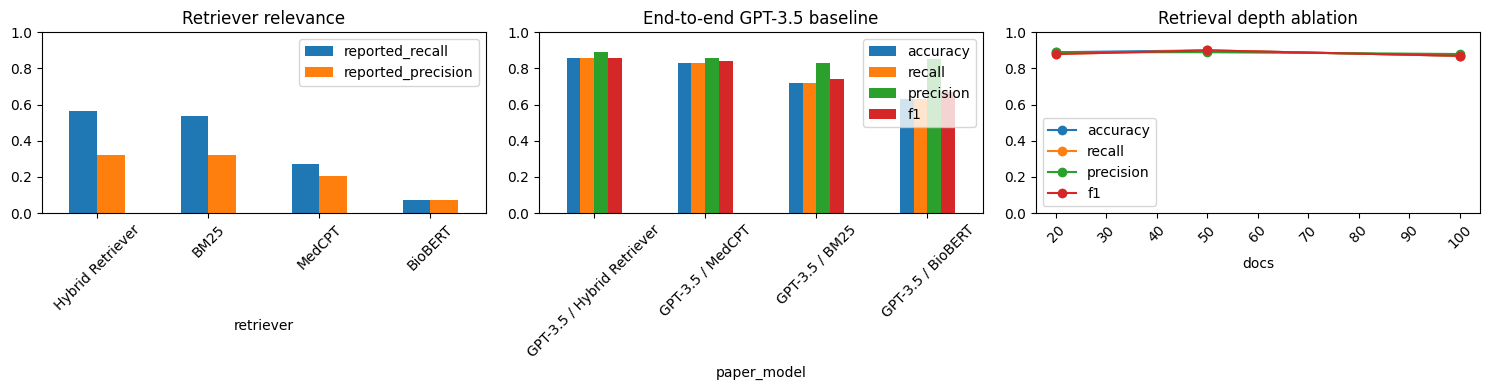

In [15]:
# 13. Reproduce Paper Figures
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
retriever_reported.plot(x='retriever', y=['reported_recall', 'reported_precision'], kind='bar', ax=axes[0], title='Retriever relevance')
e2e_reported.plot(x='paper_model', y=['accuracy', 'recall', 'precision', 'f1'], kind='bar', ax=axes[1], title='End-to-end GPT-3.5 baseline')
depth_reported.plot(x='docs', y=['accuracy', 'recall', 'precision', 'f1'], marker='o', ax=axes[2], title='Retrieval depth ablation')
for axis in axes:
    axis.set_ylim(0, 1)
    axis.tick_params(axis='x', labelrotation=45)
plt.tight_layout()
figure_path = OUTPUT_DIR / 'paper_reported_figures.png'
plt.savefig(figure_path, dpi=160, bbox_inches='tight')
figure_path

In [16]:
# 14. Run Ablation Experiments
depth_configs = [config for config in experiment_registry if config.family == 'retrieval_depth_ablation']
ablation_status = []
if RUN_FULL_EXPERIMENTS:
    for config in depth_configs:
        ablation_status.append(run_e2e_config(config))
else:
    ablation_status = [{'name': config.name, 'retrieval_depth': config.retrieval_depth, 'status': 'skipped', 'reason': 'set RUN_FULL_EXPERIMENTS=1'} for config in depth_configs]
pd.DataFrame(ablation_status)

,name,retrieval_depth,status,reason
0,hybrid_depth_20,20,skipped,set RUN_FULL_EXPERIMENTS=1
1,hybrid_depth_50,50,skipped,set RUN_FULL_EXPERIMENTS=1
2,hybrid_depth_100,100,skipped,set RUN_FULL_EXPERIMENTS=1


In [17]:
# 15. Run Error Analysis
def error_analysis(path):
    path = Path(path)
    if not path.exists():
        return pd.DataFrame([{'status': 'missing', 'path': str(path)}])
    with path.open('r', encoding='utf-8') as file:
        rows = json.load(file)
    df = pd.DataFrame(rows)
    df['is_correct'] = df['trueresponse_exact'].astype(str).str.lower() == df['ragresponse'].astype(str).str.lower()
    cols = ['questionid', 'querytype', 'question', 'trueresponse_exact', 'ragresponse', 'pmids_ground_truth', 'pmids_retrieved', 'pmids_uses_by_rag', 'retrievment_time', 'generation_time']
    return df.loc[~df['is_correct'], [col for col in cols if col in df.columns]].head(25)

first_completed = next((config.output_path for config in experiment_registry if Path(config.output_path).exists()), None)
error_analysis(first_completed) if first_completed else pd.DataFrame([{'status': 'no completed result files yet'}])

,status
0,no completed result files yet


In [18]:
# 16. Validate Reproducibility
checks = {
    'paper_pdf_parsed': len(paper_text) > 1000,
    'registry_has_e2e_retrievers': set(registry_df['retriever_id'].dropna().astype(int)) >= {1, 2, 3, 4},
    'registry_has_depths_20_50_100': {20, 50, 100}.issubset(set(registry_df['retrieval_depth'].dropna().astype(int))),
    'reported_tables_loaded': all(len(df) > 0 for df in [storage_reported, retriever_reported, e2e_reported, depth_reported]),
    'metrics_in_bounds_or_missing': metrics_df.query("status == 'computed'")[['accuracy', 'recall', 'precision', 'f1']].apply(lambda col: col.between(0, 1).all()).all() if (metrics_df['status'] == 'computed').any() else True,
}
assert all(checks.values()), checks
checks

{'paper_pdf_parsed': True,
 'registry_has_e2e_retrievers': True,
 'registry_has_depths_20_50_100': True,
 'reported_tables_loaded': True,
 'metrics_in_bounds_or_missing': True}

In [19]:
# 17. Export Results and Notebook Artifacts
import zipfile

registry_path = OUTPUT_DIR / 'experiment_registry.json'
metrics_path = OUTPUT_DIR / 'gemma_metrics.csv'
paper_protocol_path = OUTPUT_DIR / 'paper_protocol.json'
registry_df.to_json(registry_path, orient='records', indent=2)
metrics_df.to_csv(metrics_path, index=False)
paper_protocol_path.write_text(json.dumps(paper_protocol, indent=2), encoding='utf-8')

zip_path = OUTPUT_DIR / 'gemma_reproduction_artifacts.zip'
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zip_file:
    for artifact in OUTPUT_DIR.glob('*'):
        if artifact == zip_path or artifact.is_dir():
            continue
        zip_file.write(artifact, arcname=artifact.name)
print({'registry': str(registry_path), 'metrics': str(metrics_path), 'protocol': str(paper_protocol_path), 'zip': str(zip_path)})

{'registry': 'L:\\Works\\Freelance\\medical_RAG_system\\evaluation\\gemma_reproduction_outputs\\experiment_registry.json', 'metrics': 'L:\\Works\\Freelance\\medical_RAG_system\\evaluation\\gemma_reproduction_outputs\\gemma_metrics.csv', 'protocol': 'L:\\Works\\Freelance\\medical_RAG_system\\evaluation\\gemma_reproduction_outputs\\paper_protocol.json', 'zip': 'L:\\Works\\Freelance\\medical_RAG_system\\evaluation\\gemma_reproduction_outputs\\gemma_reproduction_artifacts.zip'}
